<a href="https://colab.research.google.com/github/ramakant-BIM/JSW-Projects/blob/main/Yolo_Shelt_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Upload File

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Shelves.zip to Shelves.zip


###Extract Zip File

In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_folder = "/content/shelf_images"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extraction Completed")

Extraction Completed


###Read images automatically

In [ ]:
import os

SUPPORTED_FORMATS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
)

image_paths = []

for root, dirs, files in os.walk(extract_folder):

    for file in files:

        if file.lower().endswith(SUPPORTED_FORMATS):

            full_path = os.path.join(root, file)

            image_paths.append(full_path)

print(f"Total Images Found: {len(image_paths)}")

Total Images Found: 9


###Verify Images

In [ ]:
for img in image_paths[:10]:
    print(img)

/content/shelf_images/Shelves/1.jpg
/content/shelf_images/Shelves/8.webp
/content/shelf_images/Shelves/14.webp
/content/shelf_images/Shelves/12.jpg
/content/shelf_images/Shelves/10.webp
/content/shelf_images/Shelves/11.webp
/content/shelf_images/Shelves/15.jpg
/content/shelf_images/Shelves/6.jpg
/content/shelf_images/Shelves/2.jpg


###Create Image Inventory table

In [ ]:
import pandas as pd

df_images = pd.DataFrame({
    "Image_Path": image_paths
})

df_images.head()

,Image_Path
0,/content/shelf_images/Shelves/1.jpg
1,/content/shelf_images/Shelves/8.webp
2,/content/shelf_images/Shelves/14.webp
3,/content/shelf_images/Shelves/12.jpg
4,/content/shelf_images/Shelves/10.webp


###Load images safely

In [ ]:
import cv2

valid_images = []

for path in image_paths:

    try:

        img = cv2.imread(path)

        if img is not None:

            valid_images.append(path)

    except:
        pass

print(f"Valid Images: {len(valid_images)}")

Valid Images: 9


###Display sample images

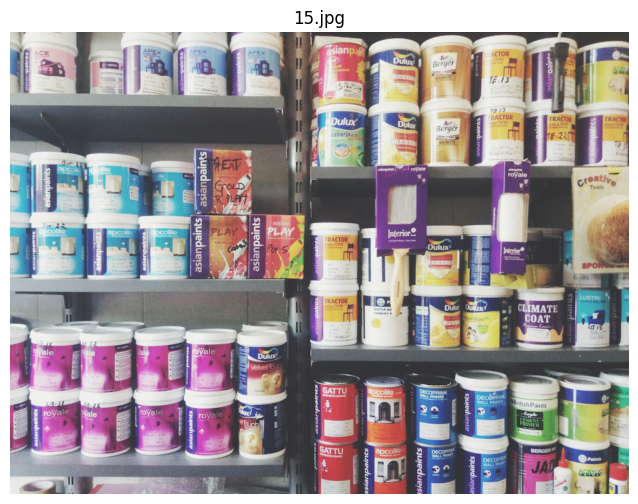

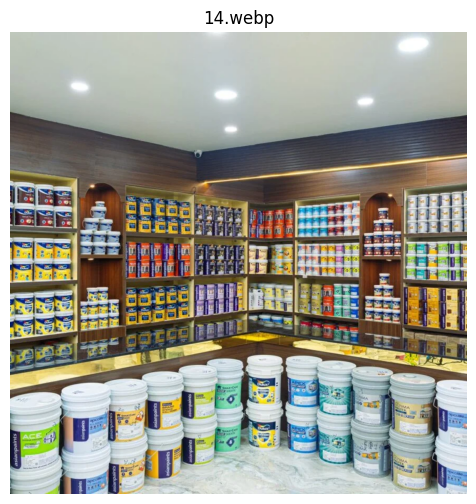

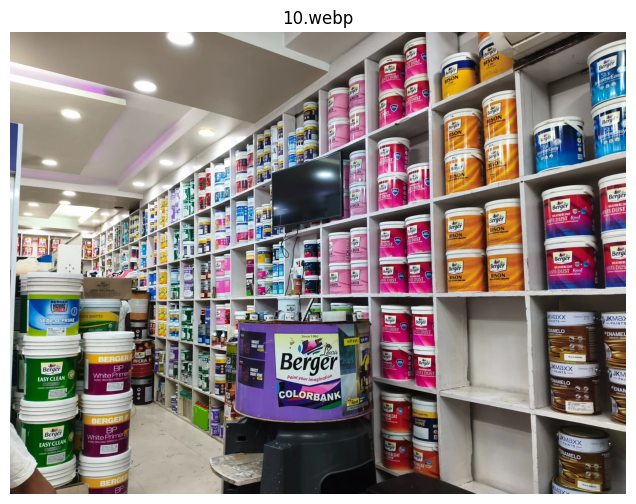

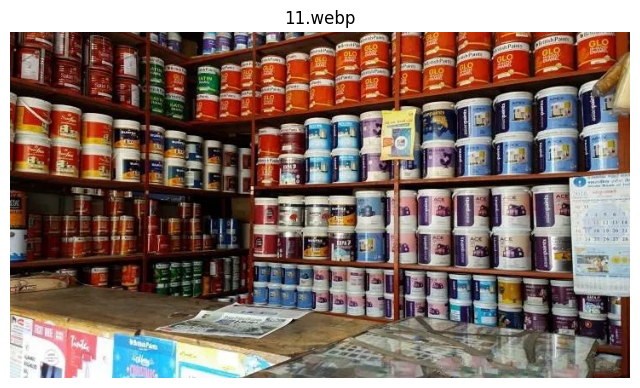

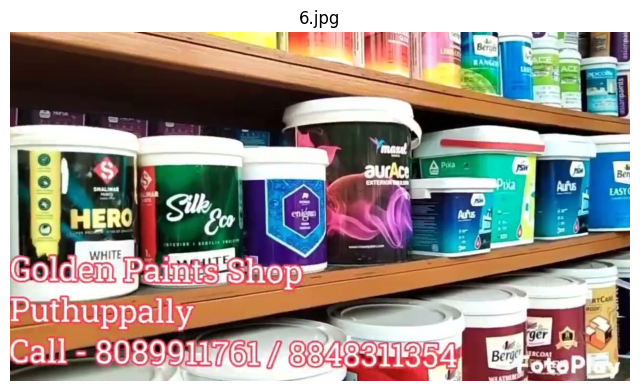

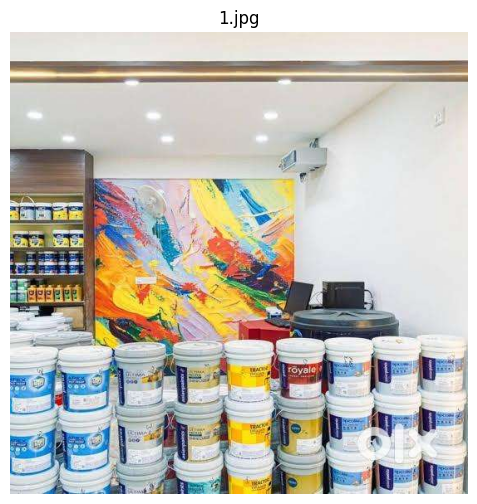

In [ ]:
import matplotlib.pyplot as plt
import random
import cv2

sample_images = random.sample(valid_images, min(6, len(valid_images)))

for path in sample_images:

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis("off")
    plt.show()

##YOLO Detection Loop

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results_storage = []

for image_path in valid_images:

    results = model(image_path)

    results_storage.append({
        "Image": image_path,
        "Result": results
    })

print("Detection Completed")


image 1/1 /content/shelf_images/Shelves/1.jpg: 640x640 7 bottles, 212.9ms
Speed: 3.8ms preprocess, 212.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/8.webp: 480x640 22 bottles, 2 refrigerators, 161.2ms
Speed: 2.8ms preprocess, 161.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/14.webp: 640x640 9 bottles, 195.8ms
Speed: 3.5ms preprocess, 195.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/12.jpg: 480x640 14 bottles, 1 refrigerator, 149.9ms
Speed: 3.0ms preprocess, 149.9ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/10.webp: 480x640 10 bottles, 149.5ms
Speed: 3.2ms preprocess, 149.5ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/11.webp: 384x640 (no detections), 122.9ms
Speed: 2.4

###Extract Bounding Boxes

In [ ]:
import pandas as pd

records = []

for image_path in valid_images:

    results = model(image_path)

    for box in results[0].boxes:

        cls = int(box.cls[0])

        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        records.append({
            "Image": image_path,
            "Class_ID": cls,
            "Confidence": confidence,
            "X1": x1,
            "Y1": y1,
            "X2": x2,
            "Y2": y2
        })

df_boxes = pd.DataFrame(records)

df_boxes.head()


image 1/1 /content/shelf_images/Shelves/1.jpg: 640x640 7 bottles, 201.7ms
Speed: 4.1ms preprocess, 201.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/8.webp: 480x640 22 bottles, 2 refrigerators, 149.9ms
Speed: 3.1ms preprocess, 149.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/14.webp: 640x640 9 bottles, 197.9ms
Speed: 4.2ms preprocess, 197.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/12.jpg: 480x640 14 bottles, 1 refrigerator, 164.0ms
Speed: 3.1ms preprocess, 164.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/10.webp: 480x640 10 bottles, 145.5ms
Speed: 3.7ms preprocess, 145.5ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/11.webp: 384x640 (no detections), 119.1ms
Speed: 2.2

,Image,Class_ID,Confidence,X1,Y1,X2,Y2
0,/content/shelf_images/Shelves/1.jpg,39,0.852602,54.451382,378.100891,124.814827,556.663391
1,/content/shelf_images/Shelves/1.jpg,39,0.837242,122.438400,372.299072,188.482285,557.000000
2,/content/shelf_images/Shelves/1.jpg,39,0.801563,0.000000,377.652496,59.723843,556.881409
3,/content/shelf_images/Shelves/1.jpg,39,0.795349,194.247147,372.514984,258.219055,557.000000
4,/content/shelf_images/Shelves/1.jpg,39,0.723444,255.877396,370.947052,319.901459,556.566833


###Shelf share calculation

In [ ]:
import cv2

shelf_results = []

for image_path in valid_images:

    image = cv2.imread(image_path)

    height, width = image.shape[:2]

    image_area = width * height

    results = model(image_path)

    brand_area = {}

    for box in results[0].boxes:

        cls = int(box.cls[0])

        x1, y1, x2, y2 = box.xyxy[0]

        area = (x2 - x1) * (y2 - y1)

        brand_area[cls] = brand_area.get(cls, 0) + area

    for cls, area in brand_area.items():

        shelf_share = area / image_area

        shelf_results.append({
            "Image": image_path,
            "Brand": cls,
            "ShelfShare": shelf_share
        })

df_shelf_share = pd.DataFrame(shelf_results)


image 1/1 /content/shelf_images/Shelves/1.jpg: 640x640 7 bottles, 198.8ms
Speed: 3.7ms preprocess, 198.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/8.webp: 480x640 22 bottles, 2 refrigerators, 145.2ms
Speed: 2.9ms preprocess, 145.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/14.webp: 640x640 9 bottles, 188.1ms
Speed: 3.6ms preprocess, 188.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/shelf_images/Shelves/12.jpg: 480x640 14 bottles, 1 refrigerator, 156.1ms
Speed: 2.8ms preprocess, 156.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/10.webp: 480x640 10 bottles, 147.8ms
Speed: 3.3ms preprocess, 147.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/shelf_images/Shelves/11.webp: 384x640 (no detections), 121.7ms
Speed: 2.2

##Save results to excel

### Convert ShelfShare to numeric values

In [ ]:
df_shelf_share['ShelfShare'] = df_shelf_share['ShelfShare'].apply(lambda x: x.item() if hasattr(x, 'item') else x)
display(df_shelf_share.head())

,Image,Brand,ShelfShare
0,/content/shelf_images/Shelves/1.jpg,39,0.272297
1,/content/shelf_images/Shelves/8.webp,72,1.475438
2,/content/shelf_images/Shelves/8.webp,39,0.451905
3,/content/shelf_images/Shelves/14.webp,39,0.195365
4,/content/shelf_images/Shelves/12.jpg,39,0.274071


In [ ]:
brand_name_mapping = model.names
df_shelf_share['Brand_Name'] = df_shelf_share['Brand'].map(brand_name_mapping)
display(df_shelf_share.head())

,Image,Brand,ShelfShare,Brand_Name
0,/content/shelf_images/Shelves/1.jpg,39,0.272297,bottle
1,/content/shelf_images/Shelves/8.webp,72,1.475438,refrigerator
2,/content/shelf_images/Shelves/8.webp,39,0.451905,bottle
3,/content/shelf_images/Shelves/14.webp,39,0.195365,bottle
4,/content/shelf_images/Shelves/12.jpg,39,0.274071,bottle


In [ ]:
# Define a dictionary to map current generic Brand_Name to desired paint brand names
brand_rename_map = {
    'bottle': 'Asian Paints',  # Example: Replace 'bottle' with 'Asian Paints'
    'refrigerator': 'Dulux',
    'bus': 'JSW Paints',
    'person': 'Opus',
    'clock': 'Nerolec' # Add other mappings as needed
}

# Apply the mapping to the 'Brand_Name' column
df_shelf_share['Brand_Name'] = df_shelf_share['Brand_Name'].map(brand_rename_map).fillna(df_shelf_share['Brand_Name']) # Use fillna to keep original names if no mapping is found

display(df_shelf_share.head())

,Image,Brand,ShelfShare,Brand_Name
0,/content/shelf_images/Shelves/1.jpg,39,0.272297,Asian Paints
1,/content/shelf_images/Shelves/8.webp,72,1.475438,Dulux
2,/content/shelf_images/Shelves/8.webp,39,0.451905,Asian Paints
3,/content/shelf_images/Shelves/14.webp,39,0.195365,Asian Paints
4,/content/shelf_images/Shelves/12.jpg,39,0.274071,Asian Paints


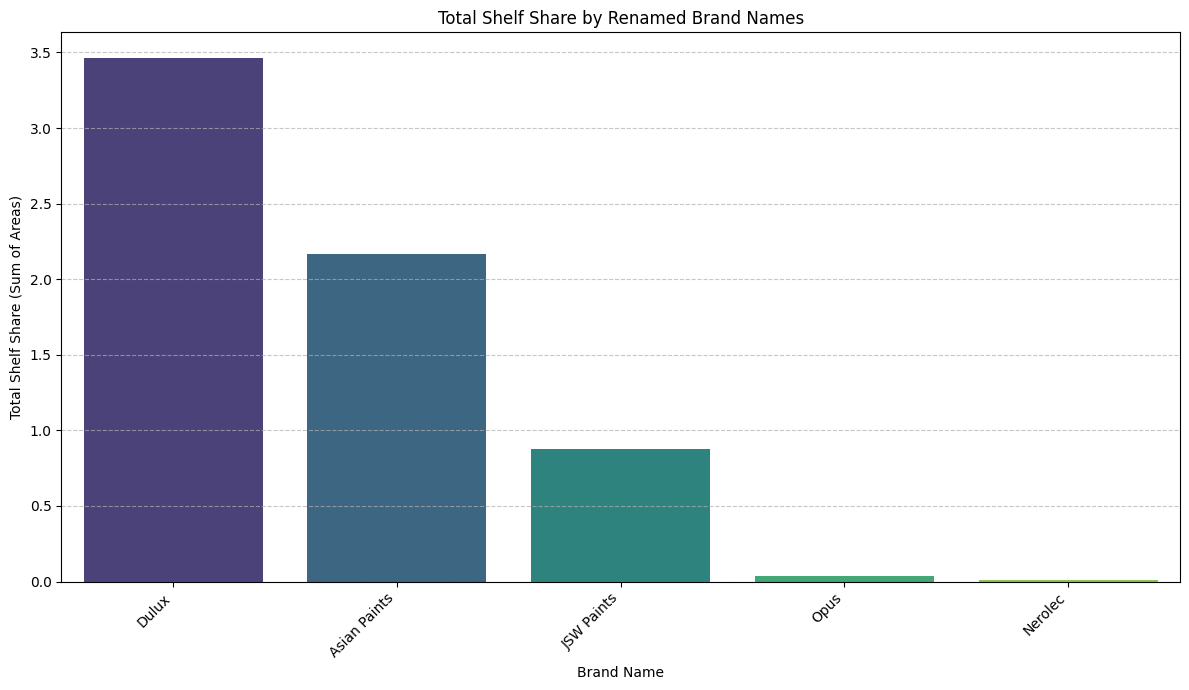

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Brand_Name' and sum the 'ShelfShare' for the renamed brands
brand_shelf_share_renamed = df_shelf_share.groupby('Brand_Name')['ShelfShare'].sum().reset_index()

# Sort for better visualization
brand_shelf_share_renamed = brand_shelf_share_renamed.sort_values(by='ShelfShare', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Brand_Name', y='ShelfShare', data=brand_shelf_share_renamed, palette='viridis', hue='Brand_Name', legend=False)
plt.title('Total Shelf Share by Renamed Brand Names')
plt.xlabel('Brand Name')
plt.ylabel('Total Shelf Share (Sum of Areas)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Bar Chart of Total Shelf Share by Renamed Brand Names

In [ ]:
output_file = "/content/Shelf_Visibility_Output.xlsx"

with pd.ExcelWriter(output_file) as writer:

    df_images.to_excel(
        writer,
        sheet_name="Image Inventory",
        index=False
    )

    df_boxes.to_excel(
        writer,
        sheet_name="YOLO Detections",
        index=False
    )

    df_shelf_share.to_excel(
        writer,
        sheet_name="Shelf Share",
        index=False
    )

print(output_file)

/content/Shelf_Visibility_Output.xlsx


###Production ready vision

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# Google Drive operations are disabled as per your request. The results will be downloaded directly.

# **FULL CODE AT ONCE**

In [ ]:
# ==========================================
# STEP 1 : INSTALL DEPENDENCIES
# ==========================================

!pip install ultralytics openpyxl -q

# ==========================================
# STEP 2 : IMPORT LIBRARIES
# ==========================================

import os
import zipfile
import cv2
import pandas as pd
from google.colab import files
from ultralytics import YOLO

# ==========================================
# STEP 3 : UPLOAD ZIP FILE
# ==========================================

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("Uploaded:", zip_file)

# ==========================================
# STEP 4 : EXTRACT ZIP
# ==========================================

extract_folder = "/content/shelf_images"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP Extracted Successfully")

# ==========================================
# STEP 5 : FIND ALL IMAGES
# ==========================================

SUPPORTED_FORMATS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
)

image_paths = []

for root, dirs, files_ in os.walk(extract_folder):

    for file in files_:

        if file.lower().endswith(SUPPORTED_FORMATS):

            image_paths.append(
                os.path.join(root, file)
            )

print(f"Total Images Found: {len(image_paths)}")

# ==========================================
# STEP 6 : VERIFY VALID IMAGES
# ==========================================

valid_images = []

for path in image_paths:

    try:

        img = cv2.imread(path)

        if img is not None:

            valid_images.append(path)

    except:

        pass

print(f"Valid Images: {len(valid_images)}")

# ==========================================
# STEP 7 : LOAD YOLO MODEL
# ==========================================

# Uses pretrained YOLO automatically

model = YOLO("yolov8n.pt")

print("YOLO Model Loaded Successfully")

# ==========================================
# STEP 8 : CREATE OUTPUT FOLDER
# ==========================================

output_folder = "/content/annotated_images"

os.makedirs(output_folder, exist_ok=True)

# ==========================================
# STEP 9 : RUN DETECTIONS
# ==========================================

all_results = []

for image_path in valid_images:

    print("Processing:", os.path.basename(image_path))

    results = model(image_path)

    result = results[0]

    annotated_image = result.plot()

    save_path = os.path.join(
        output_folder,
        os.path.basename(image_path)
    )

    cv2.imwrite(save_path, annotated_image)

    if result.boxes is not None:

        for box in result.boxes:

            class_id = int(box.cls[0])

            confidence = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0].tolist()

            width = x2 - x1
            height = y2 - y1

            box_area = width * height

            all_results.append({

                "Image": os.path.basename(image_path),

                "Class_ID": class_id,

                "Class_Name":
                model.names[class_id],

                "Confidence":
                round(confidence, 4),

                "X1": round(x1,2),
                "Y1": round(y1,2),
                "X2": round(x2,2),
                "Y2": round(y2,2),

                "Box_Area":
                round(box_area,2)

            })

print("Detection Completed")

# ==========================================
# STEP 10 : CREATE DATAFRAME
# ==========================================

df = pd.DataFrame(all_results)

print(df.head())

# ==========================================
# STEP 11 : SAVE EXCEL FILE
# ==========================================

excel_file = "/content/Shelf_Visibility_Output.xlsx"

df.to_excel(
    excel_file,
    index=False
)

print("Excel Saved")

# ==========================================
# STEP 12 : ZIP ANNOTATED IMAGES
# ==========================================

annotated_zip = "/content/Annotated_Images.zip"

with zipfile.ZipFile(
    annotated_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files_ in os.walk(output_folder):

        for file in files_:

            full_path = os.path.join(root, file)

            zipf.write(
                full_path,
                os.path.relpath(
                    full_path,
                    output_folder
                )
            )

print("Annotated Images ZIP Created")

# ==========================================
# STEP 13 : DOWNLOAD RESULTS
# ==========================================

files.download(excel_file)

files.download(annotated_zip)

Saving Shelves.zip to Shelves (1).zip
Uploaded: Shelves (1).zip
ZIP Extracted Successfully
Total Images Found: 9
Valid Images: 9
YOLO Model Loaded Successfully
Processing: 1.jpg

image 1/1 /content/shelf_images/Shelves/1.jpg: 640x640 7 bottles, 330.7ms
Speed: 9.9ms preprocess, 330.7ms inference, 29.1ms postprocess per image at shape (1, 3, 640, 640)
Processing: 8.webp

image 1/1 /content/shelf_images/Shelves/8.webp: 480x640 22 bottles, 2 refrigerators, 158.4ms
Speed: 2.9ms preprocess, 158.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Processing: 14.webp

image 1/1 /content/shelf_images/Shelves/14.webp: 640x640 9 bottles, 202.1ms
Speed: 3.5ms preprocess, 202.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Processing: 12.jpg

image 1/1 /content/shelf_images/Shelves/12.jpg: 480x640 14 bottles, 1 refrigerator, 159.4ms
Speed: 2.8ms preprocess, 159.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Processing: 10.webp

image 1/1 /

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Number of Bottles Detected per Image

### Distribution of Bottle Counts Across Images

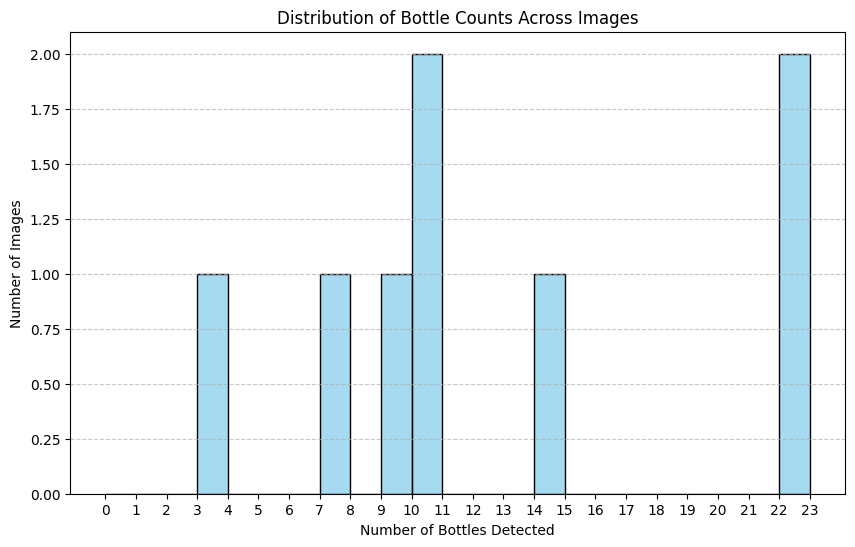

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram to visualize the distribution of bottle counts
plt.figure(figsize=(10, 6))
sns.histplot(bottle_counts['Bottle_Count'], bins=range(0, bottle_counts['Bottle_Count'].max() + 2), kde=False, color='skyblue')
plt.title('Distribution of Bottle Counts Across Images')
plt.xlabel('Number of Bottles Detected')
plt.ylabel('Number of Images')
plt.xticks(range(0, bottle_counts['Bottle_Count'].max() + 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
display(bottle_counts['Bottle_Count'].describe())

,Bottle_Count
count,8.000000
mean,12.125000
std,6.833479
min,3.000000
25%,8.500000
50%,10.000000
75%,16.000000
max,22.000000


### Shelf Share Comparison by Brand

/tmp/ipykernel_2594/2869362994.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Brand', y='ShelfShare', data=brand_shelf_share, palette='viridis')


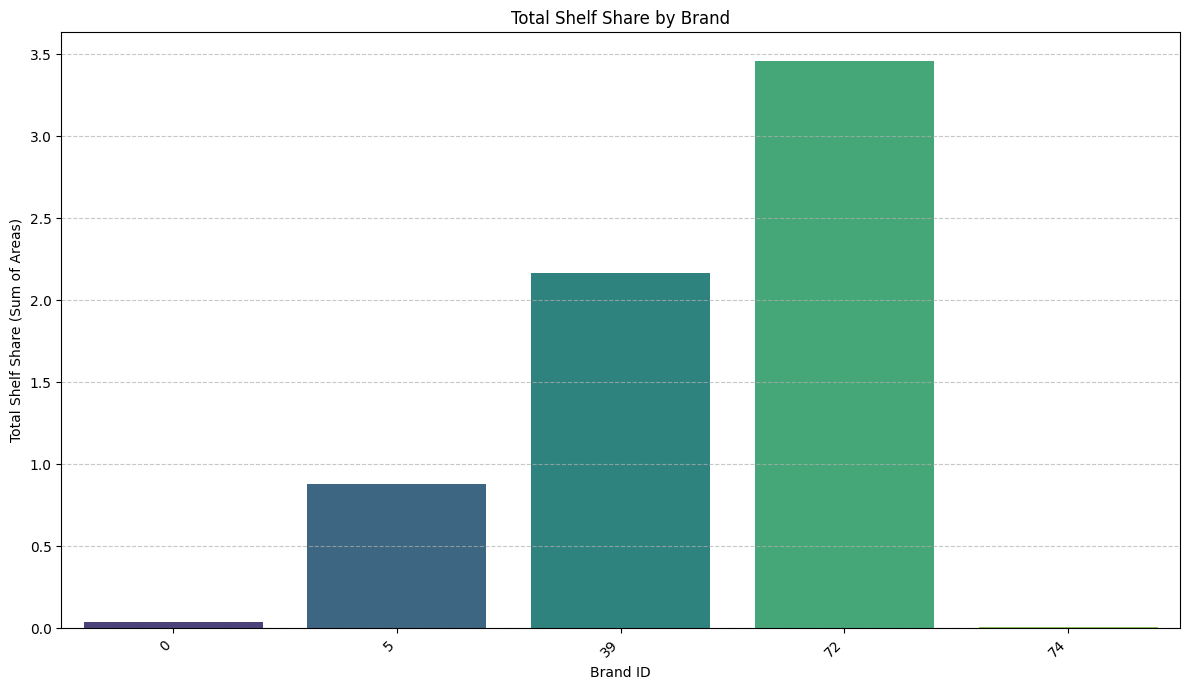

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Brand' and sum the 'ShelfShare'
brand_shelf_share = df_shelf_share.groupby('Brand')['ShelfShare'].sum().reset_index()

# Sort for better visualization
brand_shelf_share = brand_shelf_share.sort_values(by='ShelfShare', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Brand', y='ShelfShare', data=brand_shelf_share, palette='viridis')
plt.title('Total Shelf Share by Brand')
plt.xlabel('Brand ID')
plt.ylabel('Total Shelf Share (Sum of Areas)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()